In [1]:
%load_ext autoreload
%autoreload 2
import math
import os
import time
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import numpy as np
import ot as pot
import torch
import torchdyn
from torchdyn.core import NeuralODE
from torchdyn.datasets import generate_moons

from scFM_density_estimation.models import *
from scFM_density_estimation.utils import *

In [2]:
def sample_conditional_pt(x0, x1, t, sigma):
    t = t.reshape(-1, *([1] * (x0.dim() - 1)))
    mu_t = t * x1 + (1 - t) * x0
    epsilon = torch.randn_like(x0)
    return mu_t + sigma * epsilon

  0%|          | 0/20000 [00:00<?, ?it/s]

5000: loss 7.272 time 38.85


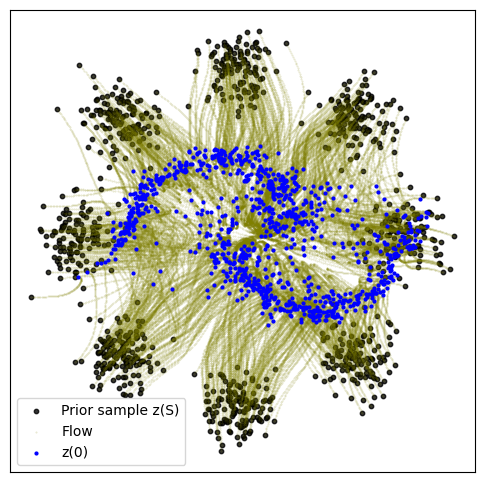

10000: loss 7.964 time 29.43


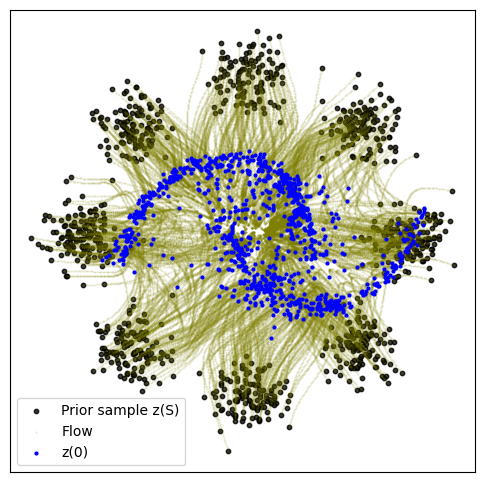

15000: loss 8.428 time 29.07


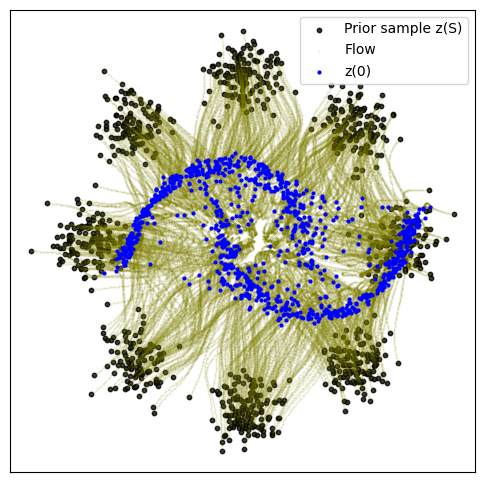

20000: loss 8.047 time 33.59


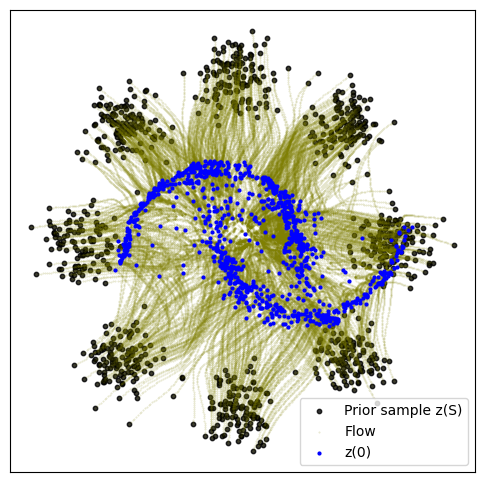

CPU times: user 25min 56s, sys: 3.65 s, total: 26min
Wall time: 2min 14s


In [3]:
%%time
sigma = 0.1
dim = 2
batch_size = 256
model = FlowMatchingMLP(input_dim=dim+1, hidden_dims=[64, 64, 64]).to("cuda")
optimizer = torch.optim.Adam(model.parameters())

start = time.time()
for k in tqdm(range(20000)):
    optimizer.zero_grad()

    x0 = sample_8gaussians(batch_size).to("cuda")
    x1 = sample_moons(batch_size).to("cuda")

    t = torch.rand(x0.shape[0]).type_as(x0).to("cuda")
    xt = sample_conditional_pt(x0, x1, t, sigma=0.01).to("cuda")
    ut = x1 - x0

    vt = model(xt, t)
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
        node = NeuralODE(
            torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            traj = node.trajectory(
                sample_8gaussians(1024).to("cuda"),
                t_span=torch.linspace(0, 1, 100).to("cuda"),
            )
            plot_trajectories(traj.cpu().numpy())

  0%|          | 0/20000 [00:00<?, ?it/s]

5000: loss 0.162 time 123.24


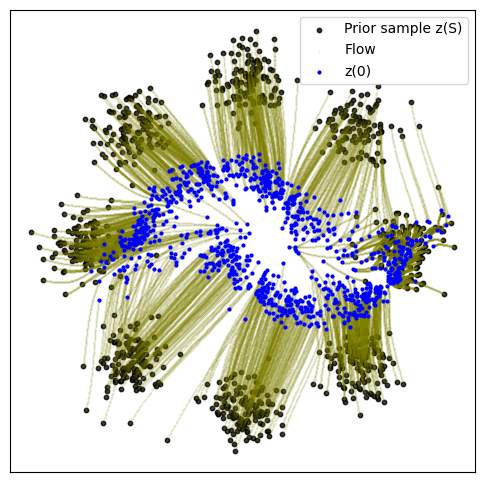

10000: loss 0.121 time 125.40


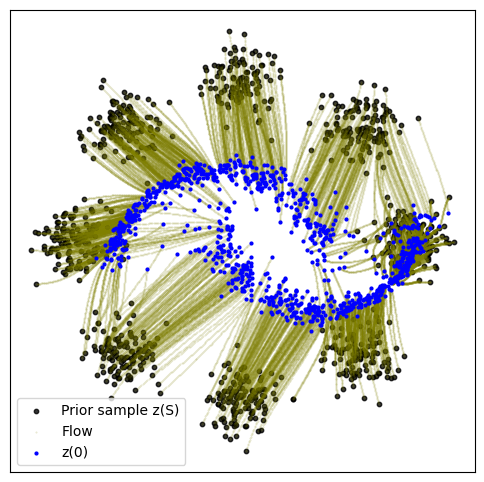

15000: loss 0.156 time 123.02


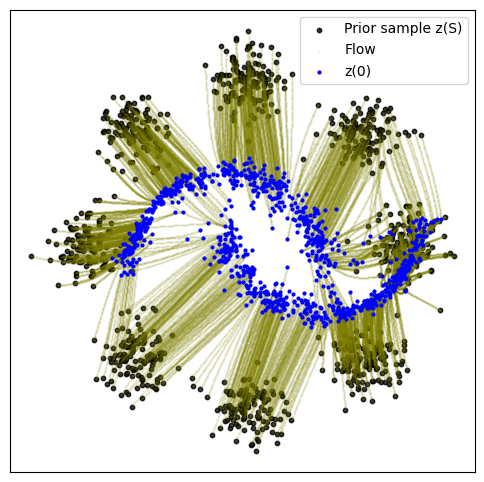

20000: loss 0.128 time 124.29


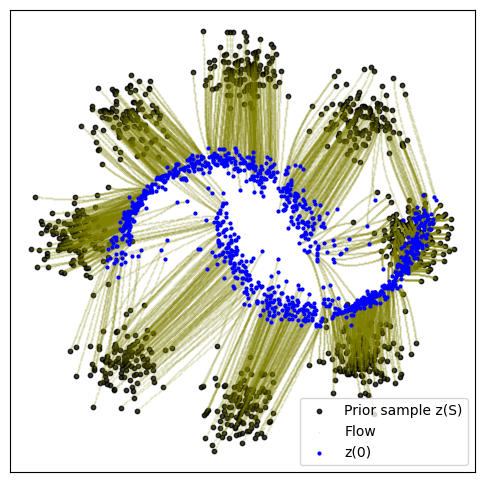

CPU times: user 37min 5s, sys: 4.94 s, total: 37min 10s
Wall time: 8min 18s


In [8]:
%%time
sigma = 0.1
dim = 2
batch_size = 256
model = FlowMatchingMLP(input_dim=dim+1, hidden_dims=[64, 64, 64]).to("cuda")
optimizer = torch.optim.Adam(model.parameters())
ot_sampler = OTPlanSampler(method="exact")

start = time.time()
for k in tqdm(range(20000)):
    optimizer.zero_grad()

    x0 = sample_8gaussians(batch_size).to("cuda")
    x1 = sample_moons(batch_size).to("cuda")

    x0, x1 = ot_sampler.sample_plan(x0, x1)

    t = torch.rand(x0.shape[0]).type_as(x0).to("cuda")
    xt = sample_conditional_pt(x0, x1, t, sigma=0.01).to("cuda")
    ut = x1 - x0

    vt = model(xt, t)
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
        node = NeuralODE(
            torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            traj = node.trajectory(
                sample_8gaussians(1024).to("cuda"),
                t_span=torch.linspace(0, 1, 100).to("cuda"),
            )
            plot_trajectories(traj.cpu().numpy())